In [1]:
!python3.11 -m pip install yfinance numpy pandas scipy matplotlib openpyxl yahooquery statsmodels

In [2]:
#Required Packages
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
from pandas.errors import Pandas4Warning
from scipy.optimize import minimize
import matplotlib.ticker as mtick
from scipy import stats
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

In [32]:
#Loading Stocks from given excel sheet
excel_sheet = "stocks.xlsx"
sheet_name = "Sheet1"
ticker_column = "Tickers"

df = pd.read_excel(excel_sheet, sheet_name=sheet_name);
tickers = df[ticker_column].dropna().tolist()

In [30]:
#Pulling data for each ticker
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365*3)).strftime('%Y-%m-%d')

print(f"Fetching Data for {len(tickers)} tickers")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

price_df = data['Close'].dropna(axis=1)
tickers = price_df.columns.tolist()
print(price_df.head())

warnings.filterwarnings('ignore', category=Pandas4Warning)

[*********************100%***********************]  6 of 6 completed

Fetching Data for 6 tickers
Ticker          AROC        CEG        FANG        FRO        NEE        WDS
Date                                                                        
2023-02-23  9.291965  77.293976  124.901093  13.479293  66.780594  19.277615
2023-02-24  9.765040  77.619049  125.589096  13.546878  66.826385  19.162918
2023-02-27  9.640078  76.737801  127.335579  13.929852  66.280357  19.597134
2023-02-28  9.881077  73.330276  124.001373  14.177664  65.514809  19.933037
2023-03-01  9.907859  72.801521  127.564926  13.907326  64.444870  20.383640


# Defining and implementing a bounds function

In [5]:
# Applying bounds so it doesnt over-allocate
def apply_bounds(weights, max_weight=0.20, tol=1e-6):
    w = weights.copy()
    n = len(w)

    while True:
        # Identify weights that violate the cap
        over = w > max_weight

        if not over.any():
            break

        # Total excess weight
        excess = (w[over] - max_weight).sum()

        # Cap the violating weights
        w[over] = max_weight

        # Redistribute excess to uncapped assets
        under = w < max_weight - tol
        if not under.any():
            break

        w[under] += excess * (w[under] / w[under].sum())

    # Final normalization (numerical safety)
    return w / w.sum()

# Hierarchical Risk Parity (HRP) Portfolio Optimization

In [6]:
# Importing additional packages
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [7]:
def cluster_var(cov, cluster):
    # Getting a sub-covariance matrix the cluster
    cov_slice = cov[np.ix_(cluster, cluster)]

    # Getting the diagonal - lower variance get higher weights since 1/smaller > 1/larger
    diag = np.diag(cov_slice)
    inv_diag = 1.0 / diag

    # Normalizing these weights
    inv_diag = inv_diag / inv_diag.sum()
    
    # Reshape for vector math
    w = inv_diag.reshape(-1, 1)
    
    # Calculating the clusters variance doing w^T * Cov * W
    return float(w.T @ cov_slice @ w)

def get_leaves(cluster_id, Z, n):
    # Base case
    if cluster_id < n:
        return [cluster_id]
        
    # If not, then split tree in half again
    left = int(Z[cluster_id - n, 0])
    right = int(Z[cluster_id - n, 1])

    # Recursively collects the leaves from both sides
    return get_leaves(left, Z, n) + get_leaves(right, Z, n)

def hrp_allocate(cov, Z):
    n = cov.shape[0]
    
    # Initialized same weightings 
    w = np.ones(n)

    def recurse(cluster_id):
        # Base case
        if cluster_id < n:
            return

        # Get child cluster from linkage tree
        left = int(Z[cluster_id - n, 0])
        right = int(Z[cluster_id - n, 1])

        # Retrive the next asset in the cluster
        left_leaves = get_leaves(left, Z, n)
        right_leaves = get_leaves(right, Z, n)

        # Compute the cluster variance
        left_var = cluster_var(cov, left_leaves)
        right_var = cluster_var(cov, right_leaves)

        # Allocate more weighting for the lower-variance cluster
        alpha = right_var / (left_var + right_var)

        # Applying weightings to both sides respectively
        w[left_leaves] *= alpha
        w[right_leaves] *= (1 - alpha)
        
        recurse(left)
        recurse(right)

    # Root node of the dendrogram
    root = 2 * n - 2
    recurse(root)

    # Normalize weights to sum to 1
    return w / w.sum()

/var/folders/7_/138wbpmx02zfdb_585wmqlqc0000gn/T/ipykernel_17635/1295552630.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(w.T @ cov_slice @ w)


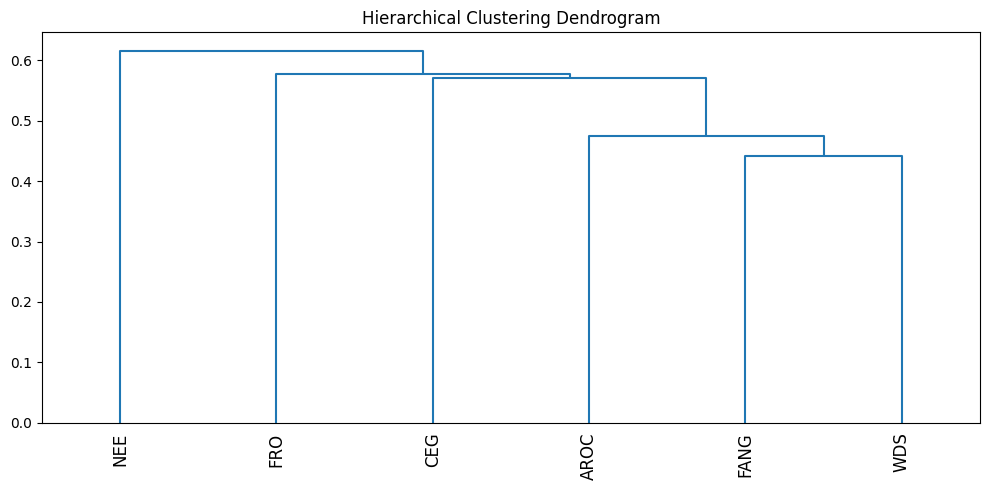

In [8]:
# Calculate percentage returns
returns = price_df.pct_change().dropna()

# Creating a correlation matrix for HERC
corr_matrix = returns.corr()

# Annualized covariance matrix
cov_matrix = returns.cov() * 252

# Converting the correlation matrix to a clustering distance matrix
dist = np.sqrt((1 - corr_matrix.values) / 2)

# Running a hierarchical clustering algorithm 
dist_condensed = squareform(dist, checks = False)
Z = linkage(dist_condensed, method="single")

# Creating fully optimized weights
hrp_weights = hrp_allocate(cov_matrix.values, Z)
hrp_weights = apply_bounds(hrp_weights, max_weight=0.20)

# Visualizing the quasi diagram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=price_df.columns, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.show()

In [9]:
# Adding updated weights to excel in a new column
# Will be used later for testing and visualization
hrp_w = pd.Series(hrp_weights, index=price_df.columns, name="HRP")

df[hrp_w.name] = df[ticker_column].map(hrp_w)

with pd.ExcelWriter(excel_sheet, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Added Updated Weights to Excel Sheet")

Added Updated Weights to Excel Sheet


## Maximum Diversification (MDP)
A simple portfolio optimization idea, maximize weighted average volatility by the total portfolio volatily. It normally rewards true diversification, not fake low variance and you can expect oiften higher Sharpe and Sortino than MVO (mean-variance)

In [21]:
def diversification(w, sigma, cov):
    num = np.dot(w, sigma)
    dem = np.sqrt(np.dot(w.T, np.dot(cov, w))) + 1e-8
    return -num / dem


def max_diversification(sigma, cov):
    n = len(sigma)

    initial_w = np.ones(n) / n

    constraints = ({
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    })

    bounds = [(0, 1) for _ in range(n)]

    cov = (cov + cov.T) / 2  # ensure symmetry

    result = minimize(
        diversification,
        initial_w,
        args=(sigma, cov),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-9}
    )

    return result.x

In [23]:
sigma = np.sqrt(np.diag(cov_matrix))
mdp_weights = max_diversification(sigma, (cov_matrix + cov_matrix.T) / 2)
print(mdp_weights)
# Adding updated weights to excel in a new column
# Will be used later for testing and visualization
mdp_w = pd.Series(mdp_weights, index=price_df.columns, name="MDP")

df[mdp_w.name] = df[ticker_column].map(mdp_w)

with pd.ExcelWriter(excel_sheet, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name=sheet_name, index=False)

print("Added Updated Weights to Excel Sheet")

[0.12672666 0.149978   0.06411012 0.19452289 0.37282834 0.091834  ]
Added Updated Weights to Excel Sheet


In [24]:
def calculate_portfolio_performance(weights, returns, risk_free_rate=0.02):
    portfolio_returns = (returns * weights).sum(axis=1)
    annual_return = portfolio_returns.mean() * 252
    annual_volatility = portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    cumulative_returns = (1 + portfolio_returns).cumprod()

    metrics = {
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Portfolio Returns": portfolio_returns,
        "Cumulative Returns": cumulative_returns
    }

    return metrics

def backtest_portfolio(weights, tickers, prices, returns, risk_free_rate=0.02, initial_capital=10000):
    metrics = calculate_portfolio_performance(weights, returns, risk_free_rate)
    portfolio_value = initial_capital * metrics["Cumulative Returns"]

    results = {
        "weights": weights,
        "tickers": tickers,
        "metrics": metrics,
        "portfolio_value": portfolio_value,
        "initial_capital": initial_capital
    }

    return results

def downside_deviation(r: pd.Series, mar_annual: float = 0.0, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) == 0: return np.nan
    mar_d = mar_annual / trading_days
    downside = np.minimum(r - mar_d, 0.0)
    return np.sqrt(np.mean(downside**2)) * np.sqrt(trading_days)

def sortino_ratio(r: pd.Series, rf_annual: float = 0.045, mar_annual: float = 0.0, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 2: return np.nan
    ann_ret = r.mean() * trading_days
    dd = downside_deviation(r, mar_annual=mar_annual, trading_days=trading_days)
    return np.nan if (not np.isfinite(dd) or dd <= 0) else (ann_ret - rf_annual) / dd

def summarize_and_plot(results_dict: dict, rf_annual: float = 0.045, trading_days: int = 252, mar_annual: float = 0.0):
    # common date index
    common = None
    for res in results_dict.values():
        idx = res["portfolio_value"].dropna().index
        common = idx if common is None else common.intersection(idx)
    if common is None or len(common) == 0:
        raise ValueError("No overlapping dates across strategies.")

    # cumulative % returns (0..100 scale)
    cum_pct = pd.DataFrame({
        name: (res["portfolio_value"].reindex(common) / res["initial_capital"] - 1.0) * 100
        for name, res in results_dict.items()
    })

    # summary metrics
    rows = []
    for name, res in results_dict.items():
        m = res["metrics"]
        ann_ret = float(m["Annual Return"])
        ann_vol = float(m["Annual Volatility"])
        risk_adj = (ann_ret - rf_annual) / ann_vol if ann_vol > 0 else np.nan

        port_rets = m["Portfolio Returns"]
        sortino = sortino_ratio(
            port_rets,
            rf_annual=rf_annual,
            mar_annual=mar_annual,
            trading_days=trading_days
        )

        rows.append({
            "Strategy": name,
            "Annual Return": ann_ret,
            "Annual Vol": ann_vol,
            "Risk Adj (Excess/Vol)": risk_adj,
            "Sortino": sortino
        })

    summary_df = pd.DataFrame(rows).set_index("Strategy")

    # format for display table
    disp = summary_df.copy()
    disp["Annual Return"] = disp["Annual Return"].map(lambda x: f"{x:.2%}" if np.isfinite(x) else "—")
    disp["Annual Vol"] = disp["Annual Vol"] .map(lambda x: f"{x:.2%}" if np.isfinite(x) else "—")
    disp["Risk Adj (Excess/Vol)"] = disp["Risk Adj (Excess/Vol)"].map(lambda x: f"{x:.3f}" if np.isfinite(x) else "—")
    disp["Sortino"] = disp["Sortino"].map(lambda x: f"{x:.3f}" if np.isfinite(x) else "—")

    colors = {'Before': '#7f212f', 'MDP': '#c2253c', 'HRP': '#300f19'}

    fig = plt.figure(figsize=(16, 5))

    ax1 = fig.add_subplot(1, 2, 1)
    cum_pct.plot(
        ax=ax1,
        linewidth=2.2,
        color=[colors.get(c, "#1f77b4") for c in cum_pct.columns]
    )

    ax1.set_title("Cumulative Returns (All Strategies)", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Cumulative Return (%)")
    ax1.legend(frameon=False)
    ax1.grid(False)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.axis("off")

    tbl = ax2.table(
        cellText=disp.values,
        rowLabels=disp.index,
        colLabels=disp.columns,
        cellLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1.1, 1.6)

    # table styling
    for (row, col), cell in tbl.get_celld().items():
        # header row
        if row == 0:
            cell.set_facecolor("#7f212f")
            cell.set_text_props(color="#FFFFFF")

        # first column (strategy names)
        if col == -1:
            cell.set_facecolor("#7f212f")
            cell.set_text_props(weight="bold", color="#FFFFFF")

        # soft borders
        cell.set_edgecolor("#7f212f")

    ax2.set_title("Performance Summary", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()
6    cum_pct.index = cum_pct.index.date2
    cum_pct.to_excel("portfolio_cumulative_returns.xlsx")
    return summary_df, cum_pct


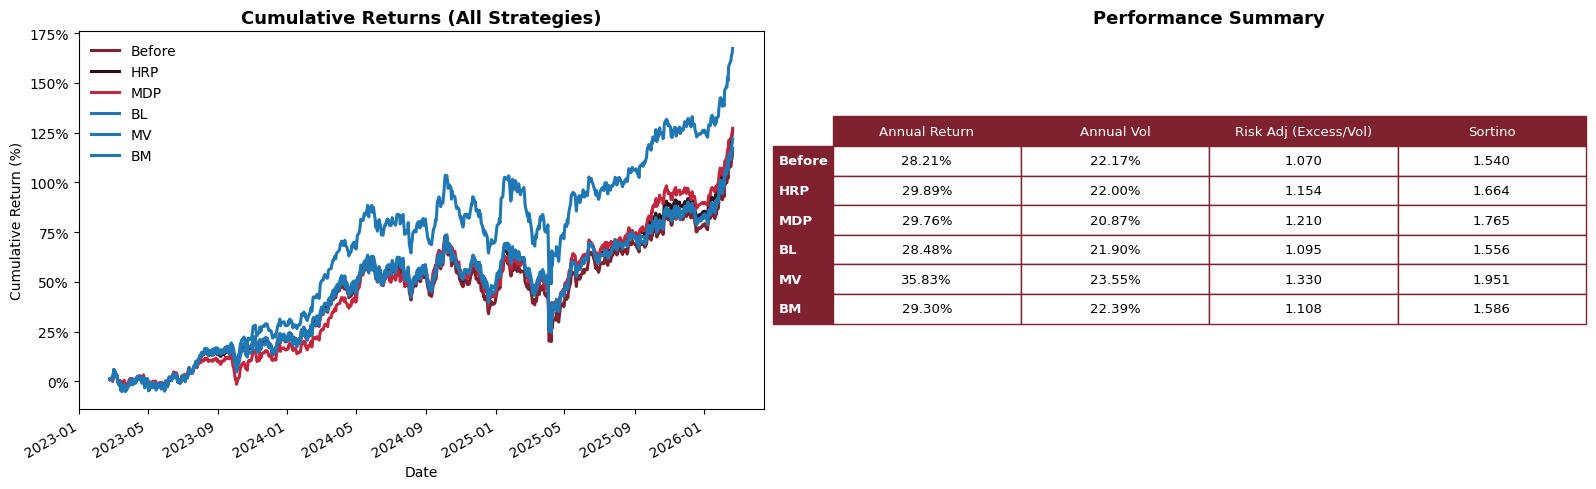

In [33]:
before_results = backtest_portfolio(df["Before"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
hrp_results    = backtest_portfolio(hrp_w, tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
mdp_results    = backtest_portfolio(mdp_w, tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
bl_results    = backtest_portfolio(df["BL"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
mv_results    = backtest_portfolio(df["MV"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
avgBM_results = backtest_portfolio(df["avg"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)

"""
aavgBM_results = backtest_portfolio(df["Average - BM"][:7].to_numpy(), tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
factor_results = backtest_portfolio(optimized_w, tickers, price_df, returns, risk_free_rate=0.045, initial_capital=10000)
"""

results_dict = {
    "Before": before_results,
    "HRP": hrp_results,
    "MDP": mdp_results,
    "BL":bl_results,
    "MV": mv_results,
    "BM" :avgBM_results
}

"""
    "Factored": factor_results,
    "BL":bl_results,
    "MV": mv_results,
    "BM" :avgBM_results,
"""

stats = summarize_and_plot(results_dict, rf_annual=0.045, trading_days=252, mar_annual=0.0)

### 